### 实验06：温度传感器标定

#### 实验内容
1. 温度-输出特性标定
2. 温度灵敏度计算
3. 线性度与精度分析
4. 温度分辨率计算
5. **T型热电偶理论值对照**
6. **热电偶补偿校正**

#### 1. 导入库与参数配置

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import os, sys

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
from plot_style import apply_measurement_style, COLORS, add_subplot_label, save_figure, SAVE_DIRS

apply_measurement_style()
SAVE_DIR = SAVE_DIRS[6]

V_REF = 5.0
LSB = V_REF / (2**15)
AMPLIFIER_GAIN = 275

#### 2. T型热电偶完整分度表 (参考温度0°C)

In [2]:
# T型热电偶完整分度表 (参考温度0°C)，单位: mV
T_TYPE_TABLE = {
    -40: -1.475, -39: -1.510, -38: -1.545, -37: -1.579, -36: -1.614, -35: -1.648, -34: -1.683, -33: -1.717, -32: -1.751, -31: -1.785,
    -30: -1.121, -29: -1.157, -28: -1.192, -27: -1.228, -26: -1.264, -25: -1.299, -24: -1.335, -23: -1.370, -22: -1.405, -21: -1.440,
    -20: -0.757, -19: -0.794, -18: -0.830, -17: -0.867, -16: -0.904, -15: -0.940, -14: -0.976, -13: -1.013, -12: -1.049, -11: -1.085,
    -10: -0.383, -9: -0.421, -8: -0.459, -7: -0.496, -6: -0.534, -5: -0.571, -4: -0.608, -3: -0.646, -2: -0.683, -1: -0.720,
    0: 0.000, 1: 0.039, 2: 0.078, 3: 0.117, 4: 0.156, 5: 0.195, 6: 0.234, 7: 0.273, 8: 0.312, 9: 0.352,
    10: 0.391, 11: 0.431, 12: 0.470, 13: 0.510, 14: 0.549, 15: 0.589, 16: 0.629, 17: 0.669, 18: 0.709, 19: 0.749,
    20: 0.790, 21: 0.830, 22: 0.870, 23: 0.911, 24: 0.951, 25: 0.992, 26: 1.033, 27: 1.074, 28: 1.114, 29: 1.155,
    30: 1.196, 31: 1.238, 32: 1.279, 33: 1.320, 34: 1.362, 35: 1.403, 36: 1.445, 37: 1.486, 38: 1.528, 39: 1.570,
    40: 1.612, 41: 1.654, 42: 1.696, 43: 1.738, 44: 1.780, 45: 1.823, 46: 1.865, 47: 1.908, 48: 1.950, 49: 1.993,
    50: 2.036, 51: 2.079, 52: 2.122, 53: 2.165, 54: 2.208, 55: 2.251, 56: 2.294, 57: 2.338, 58: 2.381, 59: 2.425,
    60: 2.468, 61: 2.512, 62: 2.556, 63: 2.600, 64: 2.643, 65: 2.687, 66: 2.732, 67: 2.776, 68: 2.820, 69: 2.864,
    70: 2.909, 71: 2.953, 72: 2.998, 73: 3.043, 74: 3.087, 75: 3.132, 76: 3.177, 77: 3.222, 78: 3.267, 79: 3.312,
    80: 3.358, 81: 3.403, 82: 3.448, 83: 3.494, 84: 3.539, 85: 3.585, 86: 3.631, 87: 3.677, 88: 3.722, 89: 3.768,
    90: 3.814, 91: 3.860, 92: 3.907, 93: 3.953, 94: 3.999, 95: 4.046, 96: 4.092, 97: 4.138, 98: 4.185, 99: 4.232,
    100: 4.279, 101: 4.325, 102: 4.372, 103: 4.419, 104: 4.466, 105: 4.513, 106: 4.561, 107: 4.608, 108: 4.655, 109: 4.702,
    110: 4.750, 111: 4.798, 112: 4.845, 113: 4.893, 114: 4.941, 115: 4.988, 116: 5.036, 117: 5.084, 118: 5.132, 119: 5.180,
    120: 5.228, 121: 5.277, 122: 5.325, 123: 5.373, 124: 5.422, 125: 5.470, 126: 5.519, 127: 5.567, 128: 5.616, 129: 5.665,
    130: 5.714, 131: 5.763, 132: 5.812, 133: 5.861, 134: 5.910, 135: 5.959, 136: 6.008, 137: 6.057, 138: 6.107, 139: 6.156,
    140: 6.206, 141: 6.255, 142: 6.305, 143: 6.355, 144: 6.404, 145: 6.454, 146: 6.504, 147: 6.554, 148: 6.604, 149: 6.654,
    150: 6.704, 151: 6.754, 152: 6.805, 153: 6.855, 154: 6.905, 155: 6.956, 156: 7.006, 157: 7.057, 158: 7.107, 159: 7.158,
}

def get_thermocouple_emf(temp):
    """从分度表直接查找温度对应的电动势(mV)"""
    temp_int = int(temp)
    if temp_int in T_TYPE_TABLE:
        return T_TYPE_TABLE[temp_int]
    else:
        raise ValueError(f"温度 {temp}°C 不在分度表范围内")

def calculate_theoretical_lsb(hot_temp, cold_temp, gain=AMPLIFIER_GAIN):
    """计算热电偶理论输出LSB值"""
    e_hot = get_thermocouple_emf(hot_temp)
    e_cold = get_thermocouple_emf(cold_temp)
    delta_e = e_hot - e_cold
    v_out = delta_e * gain / 1000
    lsb_value = v_out / LSB
    return lsb_value, delta_e

print(f"T型热电偶完整分度表已加载，范围: {min(T_TYPE_TABLE.keys())}°C ~ {max(T_TYPE_TABLE.keys())}°C")
print(f"放大增益: {AMPLIFIER_GAIN}，ADC分辨率: {LSB*1e6:.3f} μV/LSB")

T型热电偶完整分度表已加载，范围: -40°C ~ 159°C
放大增益: 275，ADC分辨率: 152.588 μV/LSB


#### 3. 热电偶补偿参数配置

In [3]:
# Cold-junction compensation temperature (integer °C)
COLD_JUNCTION_TEMP = 50

# Note: fixed COMPENSATION_OFFSET removed — full linear regression is used instead.
print(f"冷端补偿温度: {COLD_JUNCTION_TEMP}°C")
print(f"冷端电动势: {get_thermocouple_emf(COLD_JUNCTION_TEMP):.3f} mV")
print("补偿方式: 完整线性回归（替代固定偏移）")

冷端补偿温度: 50°C
冷端电动势: 2.036 mV
补偿方式: 完整线性回归（替代固定偏移）


#### 4. 数据加载函数

In [4]:
def load_sensor_data(file_path):
    df = pd.read_csv(file_path)
    df.columns = ['Time_ms', 'RawValue', 'RawGround']
    return df

def extract_stable_stats(df, start_ratio=0.3, end_ratio=0.9):
    n = len(df)
    start_idx = int(n * start_ratio)
    end_idx = int(n * end_ratio)
    stable_data = df['RawValue'].iloc[start_idx:end_idx].values
    return {'mean': np.mean(stable_data), 'std': np.std(stable_data), 'data': stable_data}

#### 5. 配置温度标定数据文件

In [5]:
import os

_BASE = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "..", "workspace", "test6")
BASE_PATH = _BASE

temperature_config = {
    25: "Temp_AD1_20251222_232738_adjusted.csv",
    30: "Temp_AD1_20251222_233538_adjusted.csv",
    35: "Temp_AD1_20251222_234632_adjusted.csv",
    40: "Temp_AD1_20251222_235249_adjusted.csv",
    45: "Temp_AD1_20251222_235931_adjusted.csv",
    50: "Temp_AD1_20251223_000738_adjusted.csv",
    55: "Temp_AD1_20251223_000950_adjusted.csv",
}

temperature_config = {temp: os.path.join(BASE_PATH, filename)
                      for temp, filename in temperature_config.items()}
T_REF = 25

#### 6. 数据采集与处理

In [6]:
temperatures = []
outputs = []
stds = []

for temp, file_path in sorted(temperature_config.items()):
    df = load_sensor_data(file_path)
    raw = df['RawValue'].values
    ground = df['RawGround'].values
    
    Q1, Q3 = np.percentile(raw, [25, 75])
    IQR = Q3 - Q1
    outlier_mask = (raw < Q1 - 3*IQR) | (raw > Q3 + 3*IQR)
    raw_clean = raw[~outlier_mask]
    ground_clean = ground[~outlier_mask]
    
    print(f"温度 {temp}°C: 异常值{np.sum(outlier_mask)}个, 有效点{len(raw_clean)}个")
    
    df_clean = pd.DataFrame({'RawValue': raw_clean, 'RawGround': ground_clean})
    stats_data = extract_stable_stats(df_clean)
    temperatures.append(temp)
    outputs.append(stats_data['mean'])
    stds.append(stats_data['std'])

temperatures = np.array(temperatures)
outputs = np.array(outputs)
stds = np.array(stds)

print("\n温度标定数据采集结果:")
print("-"*50)
for t, o, s in zip(temperatures, outputs, stds):
    print(f"{t}°C: {o:.2f} LSB (std={s:.3f})")

温度 25°C: 异常值4个, 有效点3059个
温度 30°C: 异常值2个, 有效点2849个
温度 35°C: 异常值0个, 有效点2548个
温度 40°C: 异常值2个, 有效点2999个
温度 45°C: 异常值6个, 有效点2675个
温度 50°C: 异常值4个, 有效点2571个
温度 55°C: 异常值4个, 有效点3059个

温度标定数据采集结果:
--------------------------------------------------
25°C: -2205.11 LSB (std=4.971)
30°C: -1891.55 LSB (std=5.883)
35°C: -1517.22 LSB (std=6.152)
40°C: -1193.59 LSB (std=8.404)
45°C: -753.13 LSB (std=10.737)
50°C: -359.98 LSB (std=23.844)
55°C: -35.11 LSB (std=4.971)


#### 7. T型热电偶理论值对照

In [7]:
print("="*80)
print(f"【T型热电偶理论值与实测值对照】冷端: {COLD_JUNCTION_TEMP}°C ({get_thermocouple_emf(COLD_JUNCTION_TEMP):.3f} mV)")
print("="*80)

theoretical_lsb = []
errors = []

print(f"{'热端温度':<8} {'分度表(mV)':<12} {'ΔE(mV)':<10} {'理论LSB':<12} {'实测LSB':<12} {'误差(LSB)':<10}")
print("-"*80)

for i, temp in enumerate(temperatures):
    e_hot = get_thermocouple_emf(temp)
    lsb_theory, delta_e = calculate_theoretical_lsb(temp, COLD_JUNCTION_TEMP)
    error = outputs[i] - lsb_theory
    theoretical_lsb.append(lsb_theory)
    errors.append(error)
    print(f"{temp:<8} {e_hot:<12.3f} {delta_e:<10.3f} {lsb_theory:<12.1f} {outputs[i]:<12.1f} {error:<10.1f}")

theoretical_lsb = np.array(theoretical_lsb)
errors = np.array(errors)

print("-"*80)
print(f"平均误差: {np.mean(errors):.1f} LSB，标准差: {np.std(errors):.1f} LSB")
print(f"建议补偿值: {-int(np.mean(errors))} LSB")

【T型热电偶理论值与实测值对照】冷端: 50°C (2.036 mV)
热端温度     分度表(mV)      ΔE(mV)     理论LSB        实测LSB        误差(LSB)   
--------------------------------------------------------------------------------
25       0.992        -1.044     -1881.5      -2205.1      -323.6    
30       1.196        -0.840     -1513.9      -1891.6      -377.7    
35       1.403        -0.633     -1140.8      -1517.2      -376.4    
40       1.612        -0.424     -764.1       -1193.6      -429.4    
45       1.823        -0.213     -383.9       -753.1       -369.3    
50       2.036        0.000      0.0          -360.0       -360.0    
55       2.251        0.215      387.5        -35.1        -422.6    
--------------------------------------------------------------------------------
平均误差: -379.8 LSB，标准差: 33.8 LSB
建议补偿值: 379 LSB


#### 8. 应用补偿并对照

In [8]:
# Full linear regression on raw outputs (replaces fixed +355 offset)
X_lr = temperatures.reshape(-1, 1)
model_raw = LinearRegression()
model_raw.fit(X_lr, outputs)
slope_raw = model_raw.coef_[0]
intercept_raw = model_raw.intercept_
outputs_pred_raw = model_raw.predict(X_lr)
errors_raw = outputs - outputs_pred_raw

# Keep COMPENSATION_OFFSET / outputs_compensated for downstream cells
# Use regression-predicted values as the "compensated" reference
COMPENSATION_OFFSET = int(round(-intercept_raw))   # equivalent offset for reference
outputs_compensated = outputs_pred_raw              # regression fit as compensated
errors_compensated  = errors_raw

print("="*60)
print("【完整线性回归（原始数据）】")
print("="*60)
print(f"拟合方程: Output = {slope_raw:.4f} × T + {intercept_raw:.4f}")
print(f"等效补偿值 (参考): {COMPENSATION_OFFSET} LSB")
print()
print(f"{'温度(°C)':<10} {'理论LSB':<12} {'实测LSB':<12} {'残差(LSB)':<12}")
print("-"*50)
for i, temp in enumerate(temperatures):
    print(f"{temp:<10} {theoretical_lsb[i]:<12.1f} {outputs[i]:<12.1f} {errors_raw[i]:<12.1f}")

【完整线性回归（原始数据）】
拟合方程: Output = 73.8374 × T + -4090.0231
等效补偿值 (参考): 4090 LSB

温度(°C)     理论LSB        实测LSB        残差(LSB)     
--------------------------------------------------
25         -1881.5      -2205.1      39.0        
30         -1513.9      -1891.6      -16.7       
35         -1140.8      -1517.2      -11.5       
40         -764.1       -1193.6      -57.1       
45         -383.9       -753.1       14.2        
50         0.0          -360.0       38.2        
55         387.5        -35.1        -6.1        


#### 9. 理论值与实测值对比图

Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test6\png\06_thermocouple_comparison.png


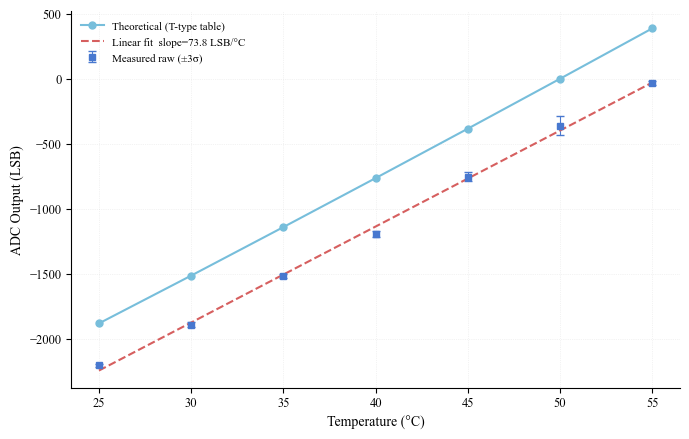

In [9]:
# ── Fig 1: Theoretical vs measured (raw regression) ──────────────────────────
fig_t, ax_t = plt.subplots(figsize=(7, 4.5))

temp_fine = np.linspace(temperatures.min(), temperatures.max(), 200)
ax_t.plot(temperatures, theoretical_lsb, "o-",
          color=COLORS["teal"], linewidth=1.5, markersize=5, label="Theoretical (T-type table)")
ax_t.errorbar(temperatures, outputs, yerr=3*stds, fmt="s",
              color=COLORS["data"], capsize=3, elinewidth=0.8, markersize=5,
              label="Measured raw (±3σ)")
ax_t.plot(temp_fine, slope_raw * temp_fine + intercept_raw,
          color=COLORS["fit"], linewidth=1.5, linestyle="--",
          label=f"Linear fit  slope={slope_raw:.1f} LSB/°C")
ax_t.set_xlabel("Temperature (°C)"); ax_t.set_ylabel("ADC Output (LSB)")
ax_t.legend(frameon=False, fontsize=8)
plt.tight_layout()
p = save_figure(fig_t, SAVE_DIR, "06_thermocouple_comparison")
print(f"Saved: {p}")
plt.show()

#### 10. 线性回归拟合

In [10]:
# Use raw outputs for calibration (full linear regression, no fixed offset)
X = temperatures.reshape(-1, 1)
y = outputs

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_
y_pred = model.predict(X)
residuals = y - y_pred

print("="*60)
print("【线性回归结果】（原始数据，完整线性回归）")
print("="*60)
print(f"拟合方程: Output = {slope:.4f} × T + {intercept:.4f}")
print(f"温度灵敏度: {slope:.4f} LSB/°C = {slope * LSB * 1000:.4f} mV/°C")

【线性回归结果】（原始数据，完整线性回归）
拟合方程: Output = 73.8374 × T + -4090.0231
温度灵敏度: 73.8374 LSB/°C = 11.2667 mV/°C


#### 11. 精度与线性度分析

In [11]:
R2 = r2_score(y, y_pred)
RMSE_LSB = np.sqrt(mean_squared_error(y, y_pred))
RMSE_degC = RMSE_LSB / abs(slope)
max_error_LSB = np.max(np.abs(residuals))
max_error_degC = max_error_LSB / abs(slope)
output_span = y.max() - y.min()
nonlinearity_FS = (max_error_LSB / output_span) * 100

print("="*60)
print("【精度与线性度分析】")
print("="*60)
print(f"温度范围: {temperatures.min()} ~ {temperatures.max()} °C")
print(f"R²: {R2:.6f}")
print(f"RMSE: {RMSE_LSB:.4f} LSB ({RMSE_degC:.4f} °C)")
print(f"最大误差: {max_error_LSB:.4f} LSB ({max_error_degC:.4f} °C)")
print(f"非线性度: {nonlinearity_FS:.4f} %FS")

【精度与线性度分析】
温度范围: 25 ~ 55 °C
R²: 0.998200
RMSE: 31.3560 LSB (0.4247 °C)
最大误差: 57.0649 LSB (0.7728 °C)
非线性度: 2.6297 %FS


#### 12. 温度分辨率计算

In [12]:
avg_std = np.mean(stds)
temp_resolution_1sigma = avg_std / abs(slope)
temp_resolution_3sigma = 3 * temp_resolution_1sigma

print("="*60)
print("【温度分辨率分析】")
print("="*60)
print(f"平均噪声: {avg_std:.2f} LSB")
print(f"1σ分辨率: {temp_resolution_1sigma:.4f} °C")
print(f"3σ分辨率: {temp_resolution_3sigma:.4f} °C")

【温度分辨率分析】
平均噪声: 9.28 LSB
1σ分辨率: 0.1257 °C
3σ分辨率: 0.3771 °C


#### 13. 标定曲线图

Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test6\png\06_temperature_calibration.png


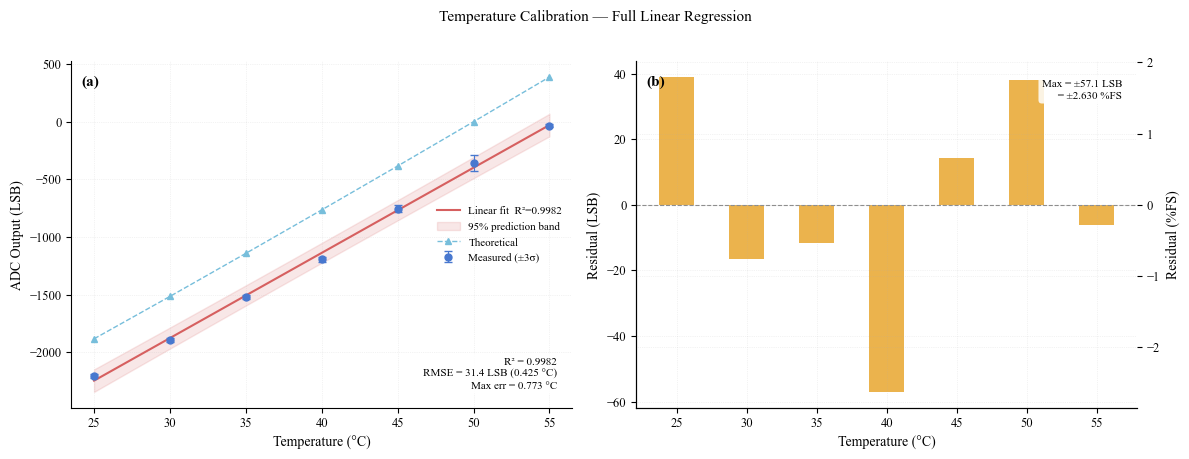

Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test6\png\06a_calibration.png
Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test6\png\06b_residuals.png


In [13]:
# ── Fig 2: 2-panel temperature calibration ───────────────────────────────────
# (a) measured points + linear regression + 95% prediction band + theoretical line
# (b) residuals in LSB with %FS dual axis

# 95% prediction band via t-distribution
n = len(temperatures)
t_crit = stats.t.ppf(0.975, df=n-2)
se_fit = np.sqrt(mean_squared_error(y, y_pred))
temp_fine = np.linspace(temperatures.min(), temperatures.max(), 200)
t_mean = temperatures.mean()
ss_xx = np.sum((temperatures - t_mean)**2)
pred_se = se_fit * np.sqrt(1 + 1/n + (temp_fine - t_mean)**2 / ss_xx)
pred_lo = slope * temp_fine + intercept - t_crit * pred_se
pred_hi = slope * temp_fine + intercept + t_crit * pred_se

output_span = y.max() - y.min()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) Calibration curve
ax = axes[0]
ax.errorbar(temperatures, outputs, yerr=3*stds, fmt="o",
            color=COLORS["data"], capsize=3, elinewidth=0.8, markersize=5,
            label="Measured (±3σ)")
ax.plot(temp_fine, slope * temp_fine + intercept,
        color=COLORS["fit"], linewidth=1.5,
        label=f"Linear fit  R²={R2:.4f}")
ax.fill_between(temp_fine, pred_lo, pred_hi,
                color=COLORS["fit"], alpha=0.15, label="95% prediction band")
ax.plot(temperatures, theoretical_lsb, "^--",
        color=COLORS["teal"], linewidth=1.0, markersize=4, label="Theoretical")
ax.set_xlabel("Temperature (°C)"); ax.set_ylabel("ADC Output (LSB)")
ax.text(0.97, 0.05,
        f"R² = {R2:.4f}\nRMSE = {RMSE_LSB:.1f} LSB ({RMSE_degC:.3f} °C)\nMax err = {max_error_degC:.3f} °C",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.85))
ax.legend(frameon=False, fontsize=8)
add_subplot_label(ax, "(a)")

# (b) Residuals — LSB primary, %FS secondary
ax = axes[1]
ax.bar(temperatures, residuals, color=COLORS["residual"], alpha=0.8, edgecolor="none", width=2.5)
ax.axhline(0, color=COLORS["gray"], linewidth=0.8, linestyle="--")
ax.set_xlabel("Temperature (°C)"); ax.set_ylabel("Residual (LSB)")
ax2 = ax.twinx()
ax2.set_ylabel("Residual (%FS)")
ax2.set_ylim(ax.get_ylim()[0] / abs(output_span) * 100,
             ax.get_ylim()[1] / abs(output_span) * 100)
ax2.spines["top"].set_visible(False)
ax.text(0.97, 0.95,
        f"Max = ±{max_error_LSB:.1f} LSB\n     = ±{nonlinearity_FS:.3f} %FS",
        transform=ax.transAxes, ha="right", va="top", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.85))
add_subplot_label(ax, "(b)")

fig.suptitle("Temperature Calibration — Full Linear Regression", fontsize=11, y=1.01)
plt.tight_layout()
p = save_figure(fig, SAVE_DIR, "06_temperature_calibration")
print(f"Saved: {p}")
plt.show()

# ── Individual sub-figures ────────────────────────────────────────────────────
for i, stem in enumerate(["06a_calibration", "06b_residuals"]):
    fig_s, ax_s = plt.subplots(figsize=(6, 4.5))
    if i == 0:
        ax_s.errorbar(temperatures, outputs, yerr=3*stds, fmt="o",
                      color=COLORS["data"], capsize=3, elinewidth=0.8, markersize=5)
        ax_s.plot(temp_fine, slope * temp_fine + intercept, color=COLORS["fit"], linewidth=1.5)
        ax_s.fill_between(temp_fine, pred_lo, pred_hi, color=COLORS["fit"], alpha=0.15)
        ax_s.plot(temperatures, theoretical_lsb, "^--",
                  color=COLORS["teal"], linewidth=1.0, markersize=4)
        ax_s.set_xlabel("Temperature (°C)"); ax_s.set_ylabel("ADC Output (LSB)")
        ax_s.text(0.97, 0.05,
                  f"R² = {R2:.4f}\nRMSE = {RMSE_LSB:.1f} LSB ({RMSE_degC:.3f} °C)",
                  transform=ax_s.transAxes, ha="right", va="bottom", fontsize=8,
                  bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.85))
    else:
        ax_s.bar(temperatures, residuals, color=COLORS["residual"], alpha=0.8, edgecolor="none", width=2.5)
        ax_s.axhline(0, color=COLORS["gray"], linewidth=0.8, linestyle="--")
        ax_s.set_xlabel("Temperature (°C)"); ax_s.set_ylabel("Residual (LSB)")
        ax2s = ax_s.twinx()
        ax2s.set_ylabel("Residual (%FS)")
        ax2s.set_ylim(ax_s.get_ylim()[0] / abs(output_span) * 100,
                      ax_s.get_ylim()[1] / abs(output_span) * 100)
        ax2s.spines["top"].set_visible(False)
    plt.tight_layout()
    p = save_figure(fig_s, SAVE_DIR, stem)
    print(f"Saved: {p}")
    plt.close(fig_s)

#### 14. 温度计算函数

In [14]:
def calculate_temperature(adc_value, apply_compensation=True):
    """根据ADC值计算温度"""
    if apply_compensation:
        adc_value = adc_value + COMPENSATION_OFFSET
    return (adc_value - intercept) / slope

print(f"温度计算公式: T = (ADC + {COMPENSATION_OFFSET} - {intercept:.2f}) / {slope:.4f}")

温度计算公式: T = (ADC + 4090 - -4090.02) / 73.8374


#### 15. 结果汇总

In [15]:
temp_cal_params = {
    'Sensitivity_LSB_per_degC': slope,
    'Intercept_LSB': intercept,
    'Compensation_Offset_LSB': COMPENSATION_OFFSET,
    'Cold_Junction_Temp_degC': COLD_JUNCTION_TEMP,
    'R2': R2,
    'RMSE_degC': RMSE_degC,
    'Max_Error_degC': max_error_degC,
    'Resolution_1sigma_degC': temp_resolution_1sigma
}
pd.DataFrame([temp_cal_params]).to_csv('06_temperature_params.csv', index=False)

df_temp_cal = pd.DataFrame({
    'Temperature_degC': temperatures,
    'Theoretical_LSB': theoretical_lsb,
    'Output_Raw_LSB': outputs,
    'Output_Compensated_LSB': outputs_compensated,
    'Std_LSB': stds
})
df_temp_cal.to_csv('06_temperature_data.csv', index=False)

print("="*60)
print("【结果汇总】")
print("="*60)
print(f"冷端温度: {COLD_JUNCTION_TEMP}°C, 补偿值: {COMPENSATION_OFFSET} LSB")
print(f"标定方程: Output = {slope:.4f} × T + {intercept:.4f}")
print(f"灵敏度: {slope:.4f} LSB/°C")
print(f"R²: {R2:.6f}, RMSE: {RMSE_degC:.4f}°C, 最大误差: {max_error_degC:.4f}°C")
print(f"1σ分辨率: {temp_resolution_1sigma:.4f}°C")
print("\n已保存: 06_temperature_params.csv, 06_temperature_data.csv")

【结果汇总】
冷端温度: 50°C, 补偿值: 4090 LSB
标定方程: Output = 73.8374 × T + -4090.0231
灵敏度: 73.8374 LSB/°C
R²: 0.998200, RMSE: 0.4247°C, 最大误差: 0.7728°C
1σ分辨率: 0.1257°C

已保存: 06_temperature_params.csv, 06_temperature_data.csv
